Iteration Comparison:
Tolerance: 0.001
Jacobi iterations: 4
Gauss-Seidel iterations: 4

Tolerance: 1e-06
Jacobi iterations: 7
Gauss-Seidel iterations: 5

Tolerance: 1e-09
Jacobi iterations: 9
Gauss-Seidel iterations: 7



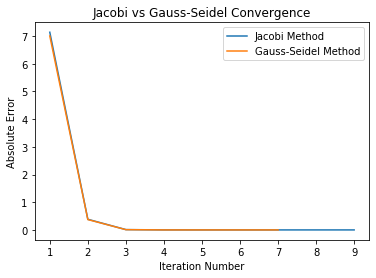

Final solution (x1, x2, x3):
[ 3.  -2.5  7. ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3.0, -0.1, -0.2],
              [0.1, 7.0, -0.3],
              [0.3, -0.2, 10.0]])

b = np.array([7.85, -19.3, 71.4])
x0 = np.array([0.0, 0.0, 0.0])
tolerances = [1e-3, 1e-6, 1e-9]


def jacobi(A, b, x0, tol, max_iter=1000):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iter):
        x_new = np.zeros(n)

        for i in range(n):
            total = 0
            for j in range(n):
                if j != i:
                    total = total + A[i][j] * x[j]

            x_new[i] = (b[i] - total) / A[i][i]

        error = np.max(np.abs(x_new - x))
        errors.append(error)

        if error < tol:
            return x_new, k + 1, errors

        x = x_new

    return x, max_iter, errors


def gauss_seidel(A, b, x0, tol, max_iter=1000):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            sum1 = 0
            for j in range(i):
                sum1 = sum1 + A[i][j] * x[j]

            sum2 = 0
            for j in range(i + 1, n):
                sum2 = sum2 + A[i][j] * x_old[j]

            x[i] = (b[i] - sum1 - sum2) / A[i][i]

        error = np.max(np.abs(x - x_old))
        errors.append(error)

        if error < tol:
            return x, k + 1, errors

    return x, max_iter, errors

# compare number of iterations required by both methods to converge.
print("Iteration Comparison:")

for tol in tolerances:
    jacobi_result = jacobi(A, b, x0, tol)
    gs_result = gauss_seidel(A, b, x0, tol)

    jacobi_iterations = jacobi_result[1]
    gs_iterations = gs_result[1]

    print("Tolerance:", tol)
    print("Jacobi iterations:", jacobi_iterations)
    print("Gauss-Seidel iterations:", gs_iterations)
    print()


# plot the convergence

jacobi_full = jacobi(A, b, x0, 1e-9)
gs_full = gauss_seidel(A, b, x0, 1e-9)

# grabbing only the errors from the functions
errors_j = jacobi_full[2]
errors_gs = gs_full[2]

# x-values
iterations_j = list(range(1, len(errors_j) + 1))
iterations_gs = list(range(1, len(errors_gs) + 1))

plt.figure()

plt.plot(iterations_j, errors_j)
plt.plot(iterations_gs, errors_gs)

plt.xlabel("Iteration Number")
plt.ylabel("Absolute Error")
plt.title("Jacobi vs Gauss-Seidel Convergence")

plt.legend(["Jacobi Method", "Gauss-Seidel Method"])

plt.show()


# solution
final_result = gauss_seidel(A, b, x0, 1e-9)
final_x = final_result[0]

print("Final solution (x1, x2, x3):")
print(np.round(final_x, 5))

# ---- Discussion ----

# A smaller tolerance requires the error to be much closer to zero, 
# so the method takes more iterations to converge. A larger tolerance 
# allows more error, so the method stops sooner and needs fewer iterations.